# ADC Bit Depth: Interactive Demo
## Gen 575 – Fundamentals of Biomedical Instrumentation

This notebook demonstrates how analog-to-digital converter (ADC) bit resolution affects the digital representation of a continuous signal.

**Key concept:** An ADC converts a continuous analog voltage into discrete digital values. The number of bits determines how many discrete levels are available:
- 3-bit ADC → 2³ = 8 levels
- 8-bit ADC → 2⁸ = 256 levels  
- 16-bit ADC → 2¹⁶ = 65,536 levels

**Run the cells below to explore how bit depth affects signal fidelity.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
%matplotlib inline

# Make plots look nice
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part 1: Static Comparison — How bit depth affects a signal

The function below digitizes a sine wave at different bit depths. Notice how lower bit depths create a "staircase" effect, losing information about the true signal shape.

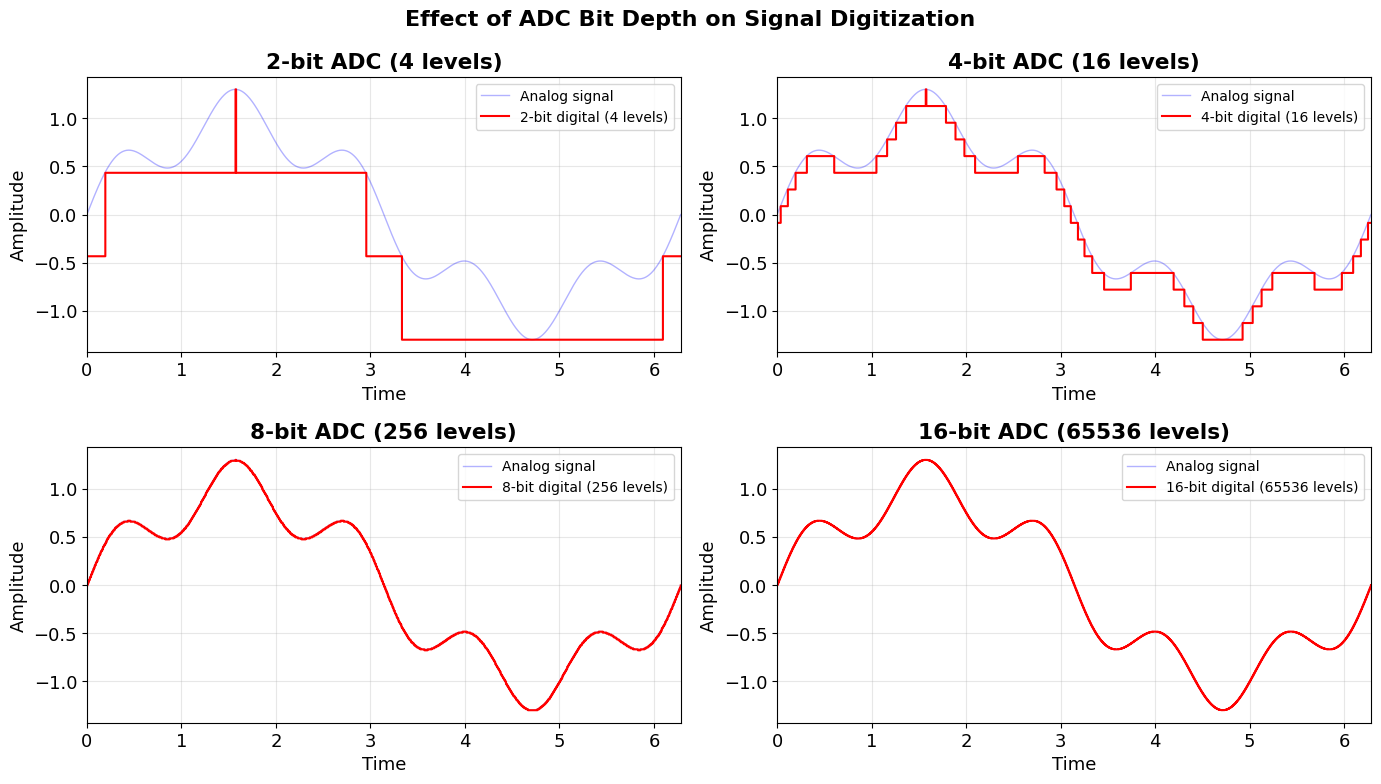

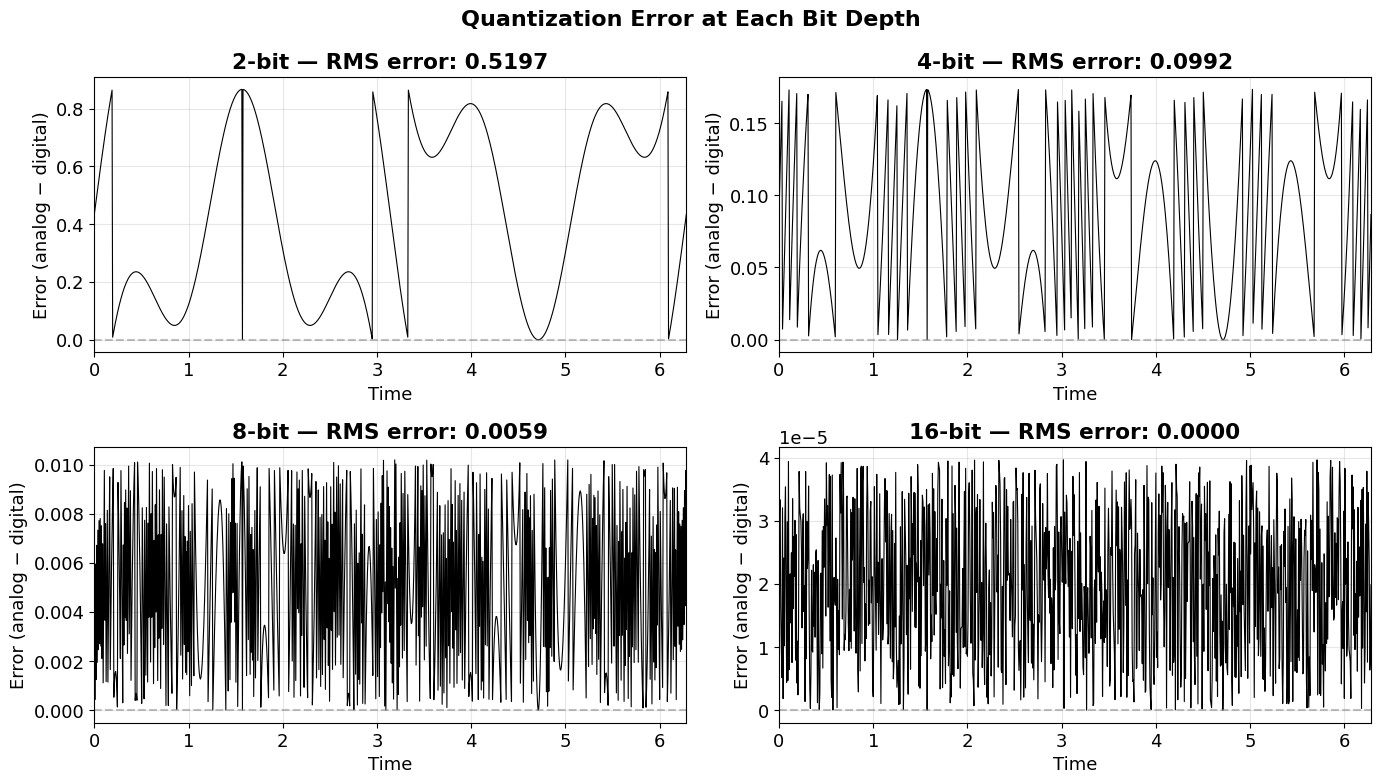

In [3]:
def digitize_signal(signal, n_bits):
    """Digitize a continuous signal using n_bits resolution."""
    n_levels = 2**n_bits
    # Map signal from its range to 0..n_levels-1, then back
    sig_min, sig_max = signal.min(), signal.max()
    # Normalize to 0-1 range
    normalized = (signal - sig_min) / (sig_max - sig_min)
    # Quantize
    quantized = np.floor(normalized * (n_levels - 1)) / (n_levels - 1)
    # Map back to original range
    return quantized * (sig_max - sig_min) + sig_min

# Generate a test signal: sum of two sine waves (like a real transducer signal)
t = np.linspace(0, 2 * np.pi, 1000)
analog_signal = np.sin(t) + 0.3 * np.sin(5 * t)  # fundamental + harmonic

# Compare different bit depths
bit_depths = [2, 4, 8, 16]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Effect of ADC Bit Depth on Signal Digitization', fontsize=16, fontweight='bold')

for ax, bits in zip(axes.flat, bit_depths):
    digital = digitize_signal(analog_signal, bits)
    n_levels = 2**bits
    
    ax.plot(t, analog_signal, 'b-', alpha=0.3, linewidth=1, label='Analog signal')
    ax.step(t, digital, 'r-', linewidth=1.5, where='post', label=f'{bits}-bit digital ({n_levels} levels)')
    ax.set_title(f'{bits}-bit ADC ({n_levels} levels)', fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(0, 2*np.pi)

plt.tight_layout()
plt.show()

# Show the quantization error
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8))
fig2.suptitle('Quantization Error at Each Bit Depth', fontsize=16, fontweight='bold')

for ax, bits in zip(axes2.flat, bit_depths):
    digital = digitize_signal(analog_signal, bits)
    error = analog_signal - digital
    rms_error = np.sqrt(np.mean(error**2))
    
    ax.plot(t, error, 'k-', linewidth=0.8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{bits}-bit — RMS error: {rms_error:.4f}', fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Error (analog − digital)')
    ax.set_xlim(0, 2*np.pi)

plt.tight_layout()
plt.show()

## Part 2: Animated ADC Resolution

Watch how increasing the bit depth progressively improves the digital approximation of the analog signal. The animation sweeps from 1-bit to 16-bit resolution.

**Note:** If the animation doesn't display inline, try running the cell again or saving the notebook and reopening.

In [4]:
fig_anim, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [3, 1]})
plt.close(fig_anim)  # prevent double display

# Analog signal
t = np.linspace(0, 2 * np.pi, 1000)
analog = np.sin(t) + 0.3 * np.sin(5 * t)

def animate(frame):
    bits = frame + 1  # 1 to 16
    n_levels = 2**bits
    digital = digitize_signal(analog, bits)
    error = analog - digital
    rms = np.sqrt(np.mean(error**2))
    
    ax1.clear()
    ax1.plot(t, analog, 'b-', alpha=0.4, linewidth=1, label='Analog signal')
    ax1.step(t, digital, 'r-', linewidth=1.5, where='post', label=f'{bits}-bit ({n_levels} levels)')
    ax1.set_xlim(0, 2*np.pi)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_ylabel('Amplitude', fontsize=12)
    ax1.set_title(f'ADC Bit Depth: {bits}-bit  ({n_levels} levels)  —  RMS Error: {rms:.6f}', 
                   fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    ax2.clear()
    ax2.fill_between(t, error, 0, color='gray', alpha=0.5)
    ax2.set_xlim(0, 2*np.pi)
    ax2.set_ylim(-0.6, 0.6)
    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Error', fontsize=12)
    ax2.set_title('Quantization Error', fontsize=12)
    ax2.grid(True, alpha=0.3)

anim = animation.FuncAnimation(fig_anim, animate, frames=16, interval=800, repeat=True)
HTML(anim.to_jshtml())

## Part 3: Why does this matter for biomedical instruments?

**Discussion questions:**

1. A mass spectrometer's detector produces a continuous current. If the ADC has only 8-bit resolution, what is the maximum dynamic range you can represent? What about 16-bit? 24-bit?

2. Your PMT signal has a peak that spans 0.1% of the ADC's full range. How many bits do you need for the peak to be represented by at least 10 discrete levels?

3. Why might you choose a lower bit-depth ADC with a faster sampling rate over a higher bit-depth ADC with a slower sampling rate? (Think about chromatographic peaks.)

**Key takeaway:** Bit depth determines the *precision* of each measurement, while sampling rate determines the *temporal resolution*. Real instruments must balance both against cost and data throughput.

In [7]:
# Quick calculator: explore the tradeoffs yourself
# Modify these parameters and re-run the cell

adc_bits = 8           # Try: 8, 10, 12, 14, 16, 20, 24
signal_fraction = 0.001  # What fraction of full range does your signal occupy?

n_levels = 2**adc_bits
levels_for_signal = n_levels * signal_fraction
dynamic_range_dB = 20 * np.log10(2**adc_bits)  # theoretical max, in dB
effective_bits_for_signal = np.log2(levels_for_signal) if levels_for_signal > 0 else 0

print(f"ADC Resolution: {adc_bits}-bit")
print(f"Total discrete levels: {n_levels:,}")
print(f"Theoretical dynamic range: {dynamic_range_dB:.1f} dB ({2**adc_bits:.1e} fold)")
print(f"")
print(f"If your signal uses {signal_fraction*100:.2f}% of full range:")
print(f"  → Signal spans {levels_for_signal:.1f} discrete levels")
print(f"  → Effective resolution for signal: {effective_bits_for_signal:.1f} bits")
if levels_for_signal < 10:
    print(f"  ⚠️  WARNING: Fewer than 10 levels — signal shape will be poorly represented!")
elif levels_for_signal < 100:
    print(f"  ⚡ Marginal: signal shape captured but quantization noise may be significant")
else:
    print(f"  ✓ Good: signal shape well-represented by the ADC")

ADC Resolution: 8-bit
Total discrete levels: 256
Theoretical dynamic range: 48.2 dB (2.6e+02 fold)

If your signal uses 0.10% of full range:
  → Signal spans 0.3 discrete levels
  → Effective resolution for signal: -2.0 bits
  ⚠️  WARNING: Fewer than 10 levels — signal shape will be poorly represented!
